## __Aprendizaje no supervisado__

__Profesor__: Anthony D. Cho

__Ayudante__: Luis Oliveros

__Asunto__: PCA

***

## Librerias

In [3]:
from time import time
from pandas import read_csv, DataFrame
from numpy import triu, ones_like

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Dataset

La data está relacionada a los atletas que han participado en el decatlon de hace 5 años, en ella contiene el registro de cada actividad, ranking y evento de competición. Esta data esta disponible en el repositorio [Kaggle - Decathlon](https://www.kaggle.com/datasets/drisskaouthar/decathlon/code) publicado por Kaouthar Driss.

<center>
    <img src='https://img.favpng.com/8/2/6/marathon-marathon-group-running-together-09wZNyv3.jpg', width=900>
</center>

In [4]:
## Carga de datos
dataset = read_csv(filepath_or_buffer='https://raw.githubusercontent.com/adoc-box/Datasets/main/decathlon.csv', 
                   index_col=0, usecols=range(13))
print('(shape) dataset: {}'.format(dataset.shape))

## Mostrar las primeras 5 filas
dataset.head()


(shape) dataset: (41, 12)


,100m,Long.jump,Shot.put,High.jump,400m,110m.hurdle,Discus,Pole.vault,Javeline,1500m,Rank,Points
SEBRLE,11.04,7.58,14.83,2.07,49.81,14.69,43.75,5.02,63.19,291.7,1,8217
CLAY,10.76,7.40,14.26,1.86,49.37,14.05,50.72,4.92,60.15,301.5,2,8122
KARPOV,11.02,7.30,14.77,2.04,48.37,14.09,48.95,4.92,50.31,300.2,3,8099
BERNARD,11.02,7.23,14.25,1.92,48.93,14.99,40.87,5.32,62.77,280.1,4,8067
YURKOV,11.34,7.09,15.19,2.10,50.42,15.31,46.26,4.72,63.44,276.4,5,8036


In [5]:
## Mostrar resumen estadístico
dataset.describe()

,100m,Long.jump,Shot.put,High.jump,400m,110m.hurdle,Discus,Pole.vault,Javeline,1500m,Rank,Points
count,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000
mean,10.998049,7.260000,14.477073,1.976829,49.616341,14.605854,44.325610,4.762439,58.316585,279.024878,12.121951,8005.365854
std,0.263023,0.316402,0.824428,0.088951,1.153451,0.471789,3.377845,0.278000,4.826820,11.673247,7.918949,342.385145
min,10.440000,6.610000,12.680000,1.850000,46.810000,13.970000,37.920000,4.200000,50.310000,262.100000,1.000000,7313.000000
25%,10.850000,7.030000,13.880000,1.920000,48.930000,14.210000,41.900000,4.500000,55.270000,271.020000,6.000000,7802.000000
50%,10.980000,7.300000,14.570000,1.950000,49.400000,14.480000,44.410000,4.800000,58.360000,278.050000,11.000000,8021.000000
75%,11.140000,7.480000,14.970000,2.040000,50.300000,14.980000,46.070000,4.920000,60.890000,285.100000,18.000000,8122.000000
max,11.640000,7.960000,16.360000,2.150000,53.200000,15.670000,51.650000,5.400000,70.520000,317.000000,28.000000,8893.000000


#### Gráfica de matriz de correlación

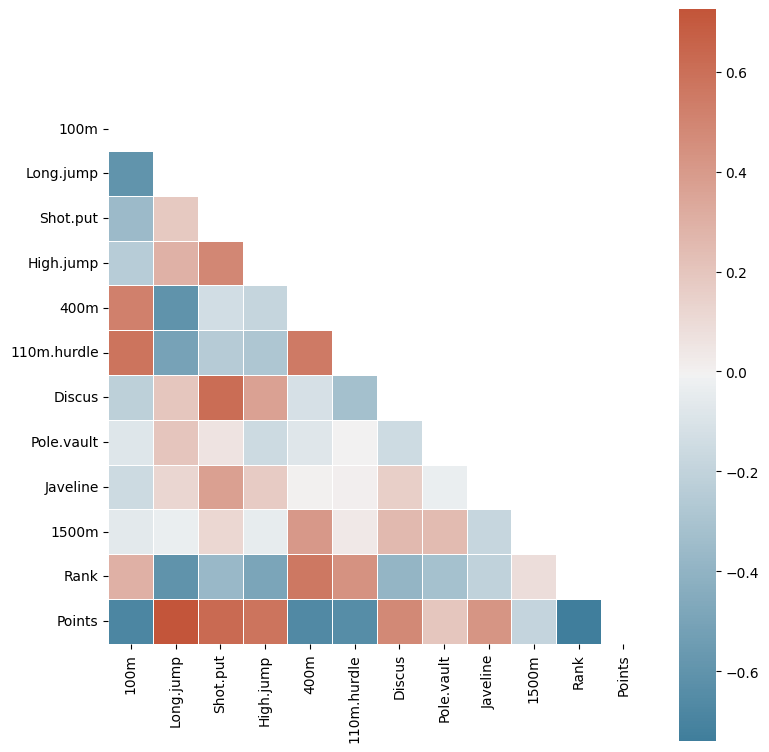

In [6]:
## Mostrar matriz de correlación

## Calculemos la matriz de correlación
corr = dataset.corr()

# Generamos una mascara para mostrar los elementos triangular inferior de la matriz de correlacion
mask = triu(ones_like(corr, dtype=bool))

# Generar una paleta de colores divergente
cmap = sns.diverging_palette(230, 20, as_cmap=True)

## Crear una instancia del espacio gráfico
plt.figure(figsize=(8, 8))

# Mapear el heatmap con la mascara en el espacio gráfico
sns.heatmap(corr, mask=mask, cmap=cmap,
            square=True, linewidths=.5)
plt.tight_layout()
plt.show()


#### Gráfica de pares de features

Time spent[s]: 5.760


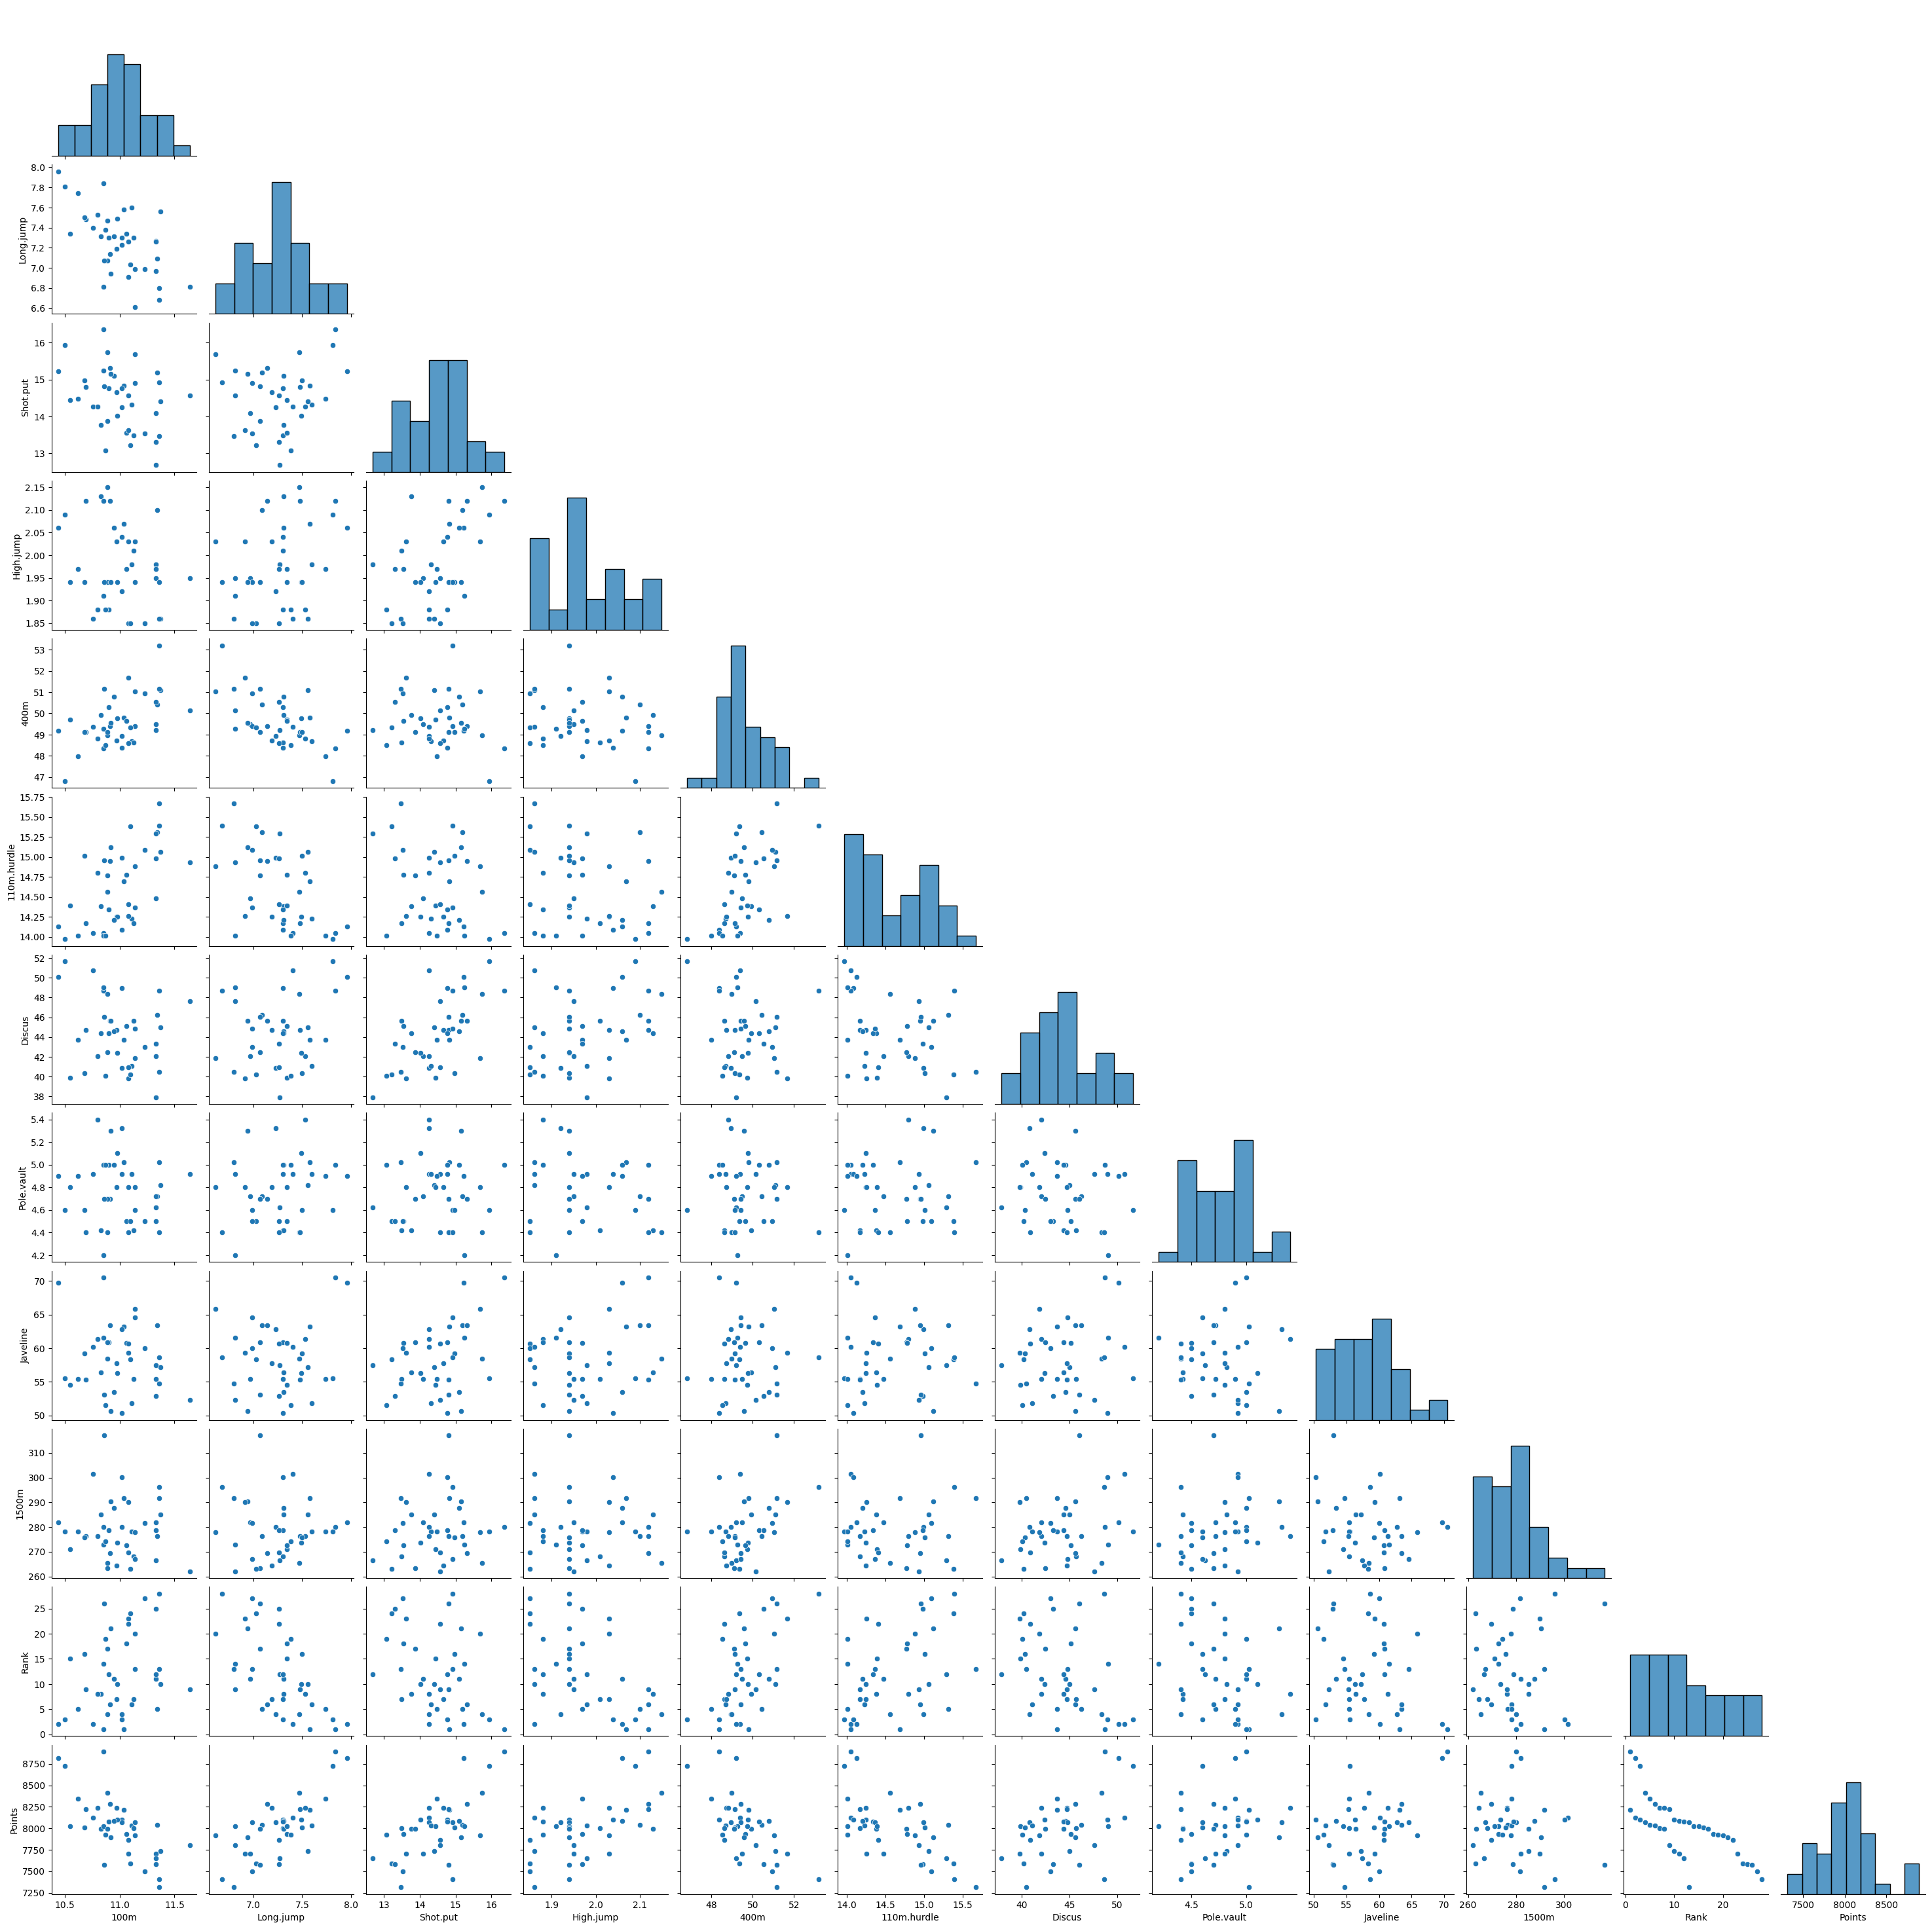

In [7]:
start = time()

## Mostrar un pairplot
sns.pairplot(data=dataset, corner=True)

timeUp = time()
print('Time spent[s]: {:.3f}'.format(timeUp -start))

## Escalado de los datos

In [8]:
## Instancia del escalador
scaler = StandardScaler()

## Ajuste del escalador
scaler.fit(dataset)

## Transformar los datos
data_scaled = scaler.transform(dataset)

## Convertir arreglo a dataframe
data_scaled = DataFrame(data=data_scaled,
                        columns=dataset.columns)

print('(shape) dataset: {}'.format(data_scaled.shape))
data_scaled.head()


(shape) dataset: (41, 12)


,100m,Long.jump,Shot.put,High.jump,400m,110m.hurdle,Discus,Pole.vault,Javeline,1500m,Rank,Points
0,0.161478,1.023937,0.433405,1.060457,0.169981,0.180572,-0.172524,0.937988,1.022196,1.099316,-1.421921,0.625796
1,-0.916293,0.447972,-0.266573,-1.329735,-0.216222,-1.192819,1.916555,0.573807,0.384558,1.949271,-1.294073,0.344884
2,0.084494,0.127992,0.359723,0.719001,-1.093956,-1.106982,1.386043,0.573807,-1.679377,1.836522,-1.166224,0.276873
3,0.084494,-0.095994,-0.278853,-0.646823,-0.602425,0.824348,-1.035731,2.030532,0.934101,0.093246,-1.038376,0.182250
4,1.316232,-0.543966,0.875496,1.401913,0.705398,1.511044,0.579784,-0.154555,1.074633,-0.227656,-0.910528,0.090584


## Modelo PCA

Existen múltiples hiperparámetros para el modelo PCA:<br>

```{python}
    pca_model = PCA(n_components=None, svd_solver='auto', 
                    tol=0.0, random_state=None)
```

| Hiperparámetros | Descripción |
|-----------------|-------------|
| __n_components__  | número de componentes (None igual al número de features).|
| __svd_solver__ | Estratégia para resolver el modelo ('auto', 'full', 'arpack', 'randomized') |
| __tol__ | Margen de tolerancia entre iteración (Solo usada para 'arpack', y 'randomized').| 
| __random_state__ | Semilla de aleatoriedad para inicialización (arpack) o selección de features (randomized).|


Para ajuste y transformación de los datos se emplean las siguientes funciones:

* __fit(X)__ : entrena el modelo usando un conjunto de datos.

* __transform(X)__: dado un modelo entrenado, transforma un conjunto de datos al espacio reducido.

In [9]:
## Instancia del modelo
pca_model = PCA()

## Ajuste del modelo
pca_model.fit(data_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


## Caracteristicas del modelo entrenado
Una vez entrenado el modelo, existen nuevas funciones y características que podemos observar (atributos)<br>

| Función | Descripción |
|-----------------|-------------|
| __get_covariance()__  | Retorna la matriz de covarianza calculada.|
| __inverse_transform(X)__ | Transforma una data del espacio reducido al espacio original. |

<br>

| Atributos | Descripción |
|-----------|-------------|
| singular_values_ | Los autovalores ordenadas en modo decreciente. |
| components_ | Los autovectores ordenadas segun los autovalores |
| explained_variance_ | La varianza explicada por cada componente principal.|
| explained_variance_ratio_ | Porcentaje de la varianza explicada por cada componente principal. |


In [ ]:
DataFrame({'Varianza': pca_model.explained_variance_,
           'Ratio.VarEx': pca_model.explained_variance_ratio_,
           'Ratio.VarEx.Acum': pca_model.explained_variance_ratio_.cumsum()
           })

__Varianza Explicada__

In [ ]:
## Numero de componentes
N = len(pca_model.explained_variance_ratio_)

plt.figure(figsize=(10, 4))
plt.bar(x=range(1, N+1), 
        height=pca_model.explained_variance_ratio_.cumsum())
plt.xlabel('Numero de componentes principales')
plt.ylabel('Ratio acumulada de varianza explicada')
plt.title('Grafica de porcentaje de varianza explicada')
plt.tight_layout()
plt.show()

## Visualización 2D

In [ ]:
## Instancia del modelo
pca_model = PCA(n_components=2)

## Ajuste del modelo
pca_model.fit(data_scaled)

#### Visualizando la correlación entre los features y los componentes principales

In [ ]:
## Se extrae los pesos de los componentes principales y se construye un dataframe
pca_components = DataFrame(data=pca_model.components_.T,
                           columns=[f'PC{i+1}' for i in range(len(pca_model.components_))])

## Se anexa los nombres de los features al dataframe
pca_components['feature'] = data_scaled.columns
pca_components

In [ ]:
plt.figure(figsize=(7, 5))
for _, row in pca_components.iterrows():
    plt.scatter(row['PC1'], row['PC2'], s=100)
    plt.arrow(
        x=0, y=0, # coordinates of arrow base
        dx=row['PC1'], # length of the arrow along x
        dy=row['PC2'], # length of the arrow along y
        color='r', 
        head_width=0.01
        )
    plt.text(row['PC1'], row['PC2'], row['feature'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

#### Visualizando los datos transformados en el espacio 2D

In [ ]:
## Se transforma los datos escalados mediante el modelo ajustado
pca_Data = pca_model.transform(data_scaled)

## Se convierte a un dataframe los datos transformados.
pca_Data = DataFrame(pca_Data,columns=["PC1","PC2"])
pca_Data.head()

In [ ]:
## Graficado de PCA
plt.figure(figsize=(7, 5))
sns.scatterplot(data=pca_Data, 
                x='PC1', y='PC2')
plt.title('Datos transformados mediante PCA')
plt.tight_layout()
plt.show()

#### Visualización de datos transformados junto con los componentes correlacionados (BiPlot)

In [ ]:
## Factor de escalado de los datos transformados (solo usado para esta grafica)
scalePC1 = 1.0/(pca_Data['PC1'].max() - pca_Data['PC1'].min())
scalePC2 = 1.0/(pca_Data['PC2'].max() - pca_Data['PC2'].min())

## Graficador
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pca_Data['PC1']*scalePC1, 
                y=pca_Data['PC2']*scalePC2)

for _, row in pca_components.iterrows():
    plt.scatter(row['PC1'], row['PC2'], s=100)
    plt.arrow(
        x=0, y=0, # coordinates of arrow base
        dx=row['PC1'], # length of the arrow along x
        dy=row['PC2'], # length of the arrow along y
        color='r', 
        head_width=0.01
        )
    plt.text(row['PC1'], row['PC2'], row['feature'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Biplot')
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
## Visualizar cuales variables estan relacionadas directamente y opuestamente a cada componente
pca_components.set_index('feature').style.applymap(lambda x: 'color: orange' if x<0 else 'color: gray')

In [ ]:
## Visualizar cuales variables están más relacionadas con cada componente. 
def hl_abs_max(x):
    s = x.abs()
    v = s.max()
    return ['background-color: red' if i==v else '' for i in s]

pca_components.set_index('feature').style.apply(hl_abs_max, axis=1)